<a href="https://colab.research.google.com/github/jegillis323/MAT-422/blob/main/MAT422_Section_2_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#MAT 422 - Section 2.3: Joint Distributions, Dependence, and Sampling

Topics: Joint Probability Distributions, Correlation and Dependence, and Random Samples

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(42)

#2.3.1 Joint Probability Distributions

In [2]:
joint = np.array([[0.10, 0.15],
                  [0.20, 0.10],
                  [0.15, 0.30]])

x_values = np.array([1, 2, 3])
y_values = np.array([0, 1])

px = joint.sum(axis=1)
py = joint.sum(axis=0)

print("Joint total =", joint.sum())
print("P(X) =", px)
print("P(Y) =", py)

print("P(Y=1 | X=3) =", joint[2, 1] / px[2])

Joint total = 1.0
P(X) = [0.25 0.3  0.45]
P(Y) = [0.45 0.55]
P(Y=1 | X=3) = 0.6666666666666667


My Explanation: A joint probability distribution describes the probability that comes from when two or more random variables are considered together. For variables $X$ and $Y$, the joint probability function is $p(x,y) = P(X=x,Y=y)$. The probabilities must be non-negative and because they sum to one, that means it is a valid probability distribution. Summing the rows gives the probability distribution of $X$ while summing the columns gives the probability distribution of $Y$. We found the conditional probability, $P(Y=1|X=3)$, by dividing the joint probability $P(X=3, Y=1)=0.3$ by $P(X=3)=0.45$

#2.3.2 Correlation and Dependence

Positive correlation = 0.913282229173394
Negative correlation = -0.9209235440842181


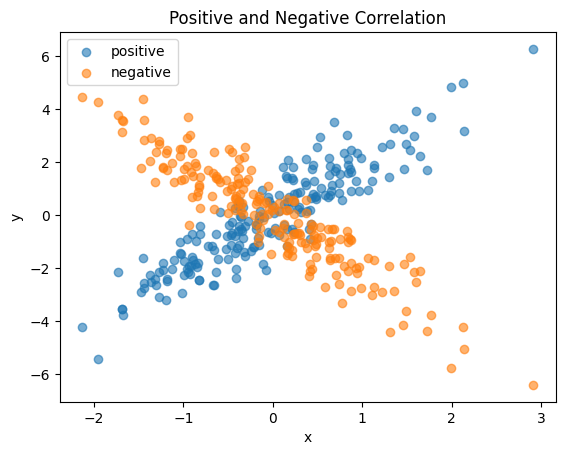

In [3]:
x = rng.normal(0, 1, 200)

y_positive = 2 * x + rng.normal(0, 0.75, 200)
y_negative = -2 * x + rng.normal(0, 0.75, 200)

print("Positive correlation =", np.corrcoef(x, y_positive)[0, 1])
print("Negative correlation =", np.corrcoef(x, y_negative)[0, 1])

plt.scatter(x, y_positive, alpha=0.6, label="positive")
plt.scatter(x, y_negative, alpha=0.6, label="negative")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Positive and Negative Correlation")
plt.show()

My Explanation: The first set of points has a strong positive correlation because $Y$ tends to increase as $X$ increases. The second has strong negative correlation because $Y$ tends to decrease as $X$ increases. The noise prevents either set from having a correlation of exactly 1 or -1. This shows that the sign of the correlation shows the direction of the linear relationship.

#2.3.3 Random Samples

Mean of sample means = 3.004205601941004
Theoretical mean = 3.0
Std of sample means = 0.4786065691950406
Theoretical standard error = 0.4743416490252569


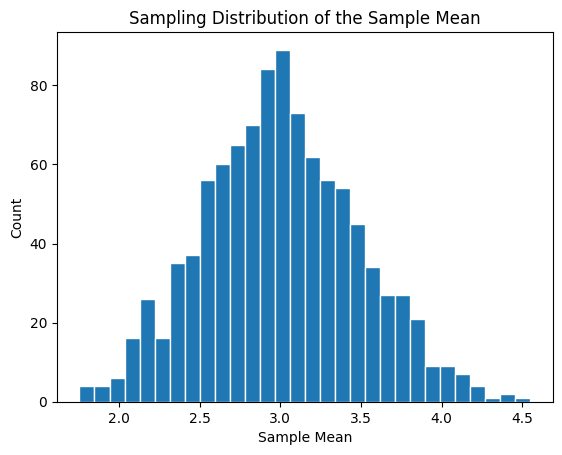

In [4]:
sample_means = []

for _ in range(1000):
    sample = rng.exponential(scale=3.0, size=40)
    sample_means.append(sample.mean())

sample_means = np.array(sample_means)

print("Mean of sample means =", sample_means.mean())
print("Theoretical mean =", 3.0)

print("Std of sample means =", sample_means.std())
print("Theoretical standard error =", 3.0 / np.sqrt(40))

plt.hist(sample_means, bins=30, edgecolor="white")
plt.title("Sampling Distribution of the Sample Mean")
plt.xlabel("Sample Mean")
plt.ylabel("Count")
plt.show()

My Explanation: The original exponential distribution has a mean and standard deviation of 3. For a sample size of 40, the sample should have a mean of 3 and a standard deviation of $\frac{3}{\sqrt{40}} \approx 0.474$. The simulated values in the graph are close to the theoretical results. It is approximately bell shaped, even if it is slightly skewed, demonstrating the Central Limit Theorem.